<a href="https://colab.research.google.com/github/juacastanori/SyS/blob/main/SyTFAudio_Ejs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Cuadernillo Transformada de Fourier Ejercicios SyS - 2024

##Juan Jerónimo Castaño Rivera

# Ejercicios

- Presente y describa el modelo que utiliza la FFT para el cálculo de los armónicos.

La FFT (Fast Fourier Transform) es un algoritmo eficiente para calcular la Transformada Discreta de Fourier (DFT) y su inversa. Funciona dividiendo recursivamente la DFT de una secuencia en transformadas más pequeñas. Esto se logra mediante la técnica de dividir y conquistar, donde la DFT de una secuencia de longitud \( N \) se divide en dos DFT de secuencias de longitud \( N/2 \).

El algoritmo FFT es especialmente eficiente cuando la longitud de la secuencia \( N \) es una potencia de 2, aunque también puede manejar otras longitudes de manera eficiente. Hay varias variantes del algoritmo FFT, siendo el algoritmo Cooley-Tukey uno de los más comunes y eficientes. La clave de este algoritmo radica en su capacidad para reducir el número de operaciones necesarias para calcular la DFT de una secuencia al dividirla en subsecuencias más pequeñas.

El algoritmo Cooley-Tukey se basa en el principio de que la DFT de una secuencia puede expresarse en términos de la DFT de sus subsecuencias. Esto se conoce como el enfoque de descomposición en factores. El algoritmo Cooley-Tukey aprovecha esta propiedad al dividir la secuencia en subsecuencias más pequeñas y luego combinar las DFT de estas subsecuencias para obtener la DFT completa de la secuencia original.

El proceso se puede visualizar de la siguiente manera:

1. **División**: La secuencia original se divide en dos subsecuencias, una consistiendo en los elementos pares y la otra en los elementos impares. Esto se repite recursivamente hasta que las secuencias sean lo suficientemente pequeñas.

2. **Cálculo de DFT de subsecuencias pequeñas**: Se calculan las DFT de las subsecuencias más pequeñas utilizando recursión. Esto puede hacerse de manera eficiente mediante el algoritmo FFT.

3. **Combinación**: Las DFT de las subsecuencias se combinan para formar la DFT de la secuencia original. Esto se hace aplicando un factor de giro y combinando las DFT de las subsecuencias de manera adecuada.

Este proceso se repite recursivamente hasta que se obtiene la DFT completa de la secuencia original. La eficiencia del algoritmo FFT proviene de la reducción del número total de operaciones necesarias al dividir la secuencia en subsecuencias más pequeñas y combinarlas de manera adecuada. Esto permite calcular la DFT en un tiempo mucho más rápido que los métodos directos, especialmente para secuencias largas.

Se sigue el modelo de la siguiente imagen para hacer los cálculos:

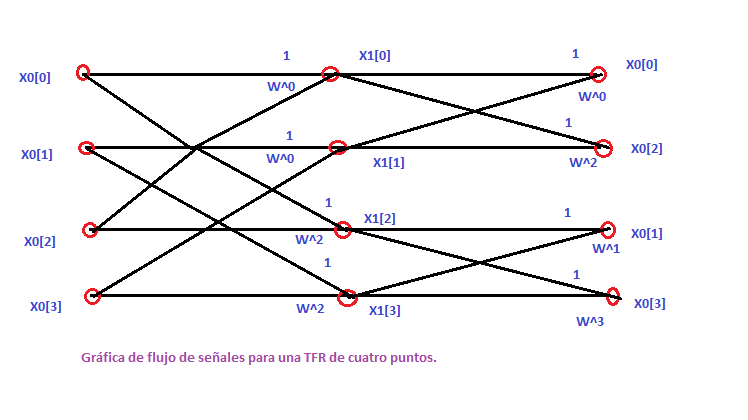


- Realice una comparación del tiempo de cómputo requerido para el cálculo de la transformada discreta de Fourier utilizado la estimación por sumatoria vs la FFT. Pruebe distintos valores de longitud de la señal de entrada (4,8,16,32,64,128,256,512,1024,2048,4096). Presente una gráfica comparativa de los tiempos de ejecución en segundos vs la longitud de la señal de entrada.



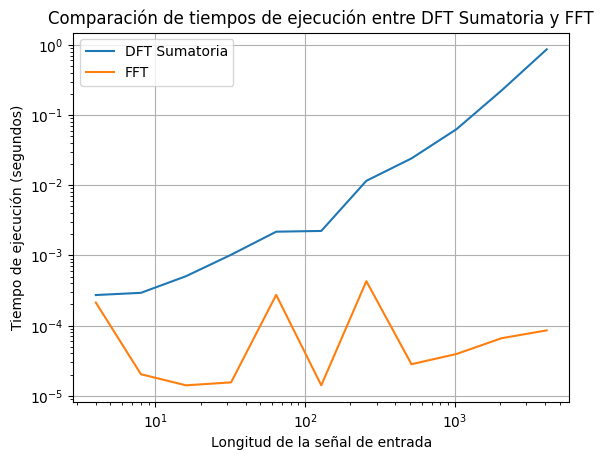

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

def dft_sum(signal):    #Transformada de Fourier por sumatoria
    K = len(signal)
    X = np.zeros(K, dtype=np.complex_)
    k=np.arange(K)
    for n in range(K):
        X[n] = np.sum(signal * np.exp(-2j * np.pi * n * k / K))
    return X

def dft_fft(signal):      #Transformada rápida de Fourier
    return np.fft.fft(signal)

# Definir las longitudes de señal de entrada a probar
lengths = [4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096]

# Lista para almacenar los tiempos de ejecución de cada método
times_sum = []
times_fft = []

# Iterar sobre las longitudes y calcular los tiempos de ejecución
for length in lengths:
    signal = np.random.rand(length)  # Generar una señal aleatoria de longitud dada / Se puede hacer también generando una señal de unos con np.ones

    # Calcular tiempo de ejecución para DFT utilizando sumatoria
    start_time = time.time()
    dft_sum(signal)
    end_time = time.time()
    time_sum = end_time - start_time
    times_sum.append(time_sum)

    # Calcular tiempo de ejecución para DFT utilizando FFT
    start_time = time.time()
    dft_fft(signal)
    end_time = time.time()
    time_fft = end_time - start_time
    times_fft.append(time_fft)

# Graficar los tiempos de ejecución
plt.plot(lengths, times_sum, label='DFT Sumatoria')
plt.plot(lengths, times_fft, label='FFT')
plt.xlabel('Longitud de la señal de entrada')
plt.ylabel('Tiempo de ejecución (segundos)')
plt.title('Comparación de tiempos de ejecución entre DFT Sumatoria y FFT')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.yscale('log')
plt.show()

Se observa que la transformada rápida es mucho más eficiente, debido a que el modelo que emplea la hace menos "pesada" para implementar

- Implemente un filtro pasa bajas, un pasa altas, un pasa bandas, y un rechaza bandas utilizando la FFT y la iFFT sobre 5 segundos de su canción favorita de YouTube.


In [ ]:
#Se instala api para descargar videos desde youtube
!python3 -m pip install --force-reinstall https://github.com/yt-dlp/yt-dlp/archive/master.tar.gz

     / 2.6 MB 9.6 MB/s 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 39.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 22.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 80.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 9.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 19.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.1/142.1 kB 18.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 9.5 MB/s eta 0:00:00
  Created wheel for yt-dlp: filename=yt_dlp-2024.4.9-py3-none-any.whl size=2827030 sha256=d8a0daae379

In [ ]:
link="https://www.youtube.com/watch?v=KWmG0ZsUAag&ab_channel=MegaSlimMarshall"
!yt-dlp --extract-audio -o "audio" --audio-format mp3 {link}

[youtube] Extracting URL: https://www.youtube.com/watch?v=KWmG0ZsUAag
[youtube] KWmG0ZsUAag: Downloading webpage
[youtube] KWmG0ZsUAag: Downloading ios player API JSON
[youtube] KWmG0ZsUAag: Downloading android player API JSON
[youtube] KWmG0ZsUAag: Downloading m3u8 information
[info] KWmG0ZsUAag: Downloading 1 format(s): 251
[download] Destination: audio
[download] 100% of    4.36MiB in 00:00:00 at 45.24MiB/s
[ExtractAudio] Destination: audio.mp3
Deleting original file audio (pass -k to keep)


In [ ]:
!ffmpeg -y -i audio.mp3 output.wav

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
!pip install soundfile

In [ ]:
import soundfile as sf # para instalar pip install soundfile
#lee archivos wav
nombre_out = "output.wav"
x, fs = sf.read(nombre_out)
# read speech signal from file
print('Frecuencia de muestreo %.2f[Hz]\naudio %s' % (fs,nombre_out))

Frecuencia de muestreo 48000.00[Hz]
audio output.wav


In [ ]:
x.shape

(13739712, 2)

In [ ]:
from IPython.display import Audio
ns = 30 #se reproducen los primeros ns segundos
Audio(x[int(fs*25):int(fs*ns),:].T,rate=fs)

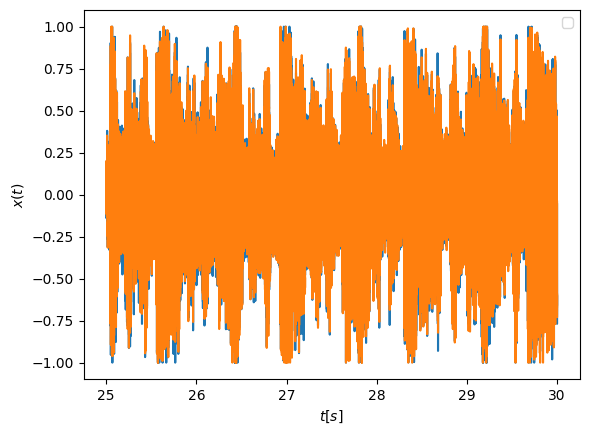

In [ ]:
xpro = x.copy() #copiar archivos para procesar
ti = 25 #tiempo incio a procesar seg
tf = 30 #tiempo final a procesar seg
xs = xpro[int(ti*fs):int((tf*fs)),:]

tt = np.arange(ti,tf,1/fs) # vector de tiempo
plt.plot(tt,xs)
plt.legend(('canal 1','canal 2'))
plt.xlabel('$t[s]$')
plt.ylabel('$x(t)$')
plt.legend()
plt.show()

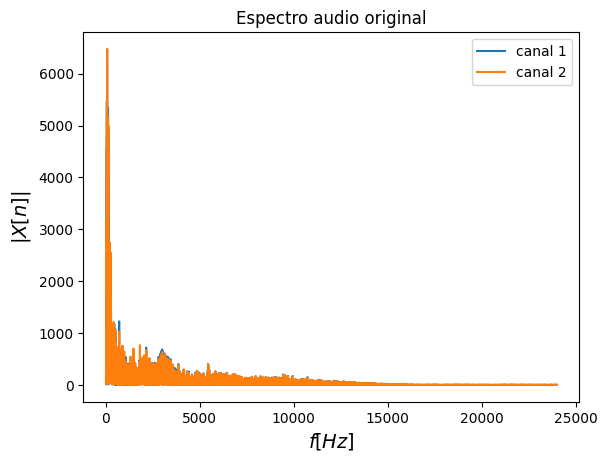

In [ ]:
#Podemos calcular la FFT y la IFFT para ver como funciona
Xw = np.fft.rfft(xs,axis=0) # axis=0 permite aplicar fft por cada columna de xpro
#Xwc1 = np.fft.rfft(xs[:,0])
#Xwc2 = np.fft.rfft(xs[:,1])
vf = np.fft.rfftfreq(np.size(xs,0),1/fs) #se crea el vector de frecuencias
plt.plot(vf,abs(Xw))#se grafica la magnitud
plt.legend(('canal 1','canal 2'))
plt.title(r'Espectro audio original')
plt.xlabel(r'$f[Hz]$',fontsize = 14)
plt.ylabel(r'$|X[n]|$',fontsize = 14)
plt.show()

In [ ]:
xio = np.fft.irfft(Xw,axis=0) #fft inversa sobre los dos canales de audio

In [ ]:
Audio(xio[:int(fs*ns),:].T,rate=fs)#repoducir señal de ifft

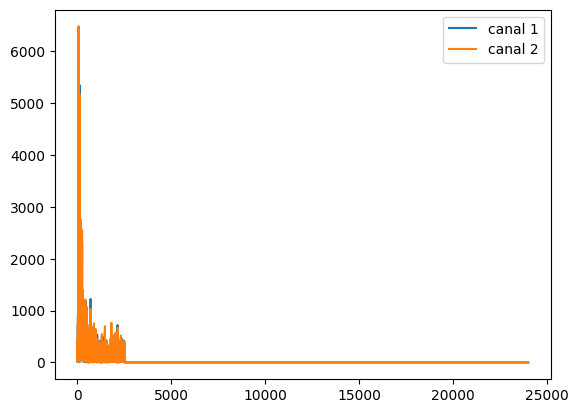

In [ ]:
#filtrar espectro pasabajas
Xwf = Xw.copy()
f1 = 2500 #frecuencia en Hz corte 1
ind = ~((vf < f1)) #frecuencias eliminar-> recueder que ~ actua como negación
Xwf[ind,:] = 0
plt.plot(vf,abs(Xwf))
plt.legend(('canal 1','canal 2'))
plt.show()

In [ ]:
xe1 = np.fft.irfft(Xwf,axis=0) #fft inversa sobre los dos canales de audio
Audio(xe1[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

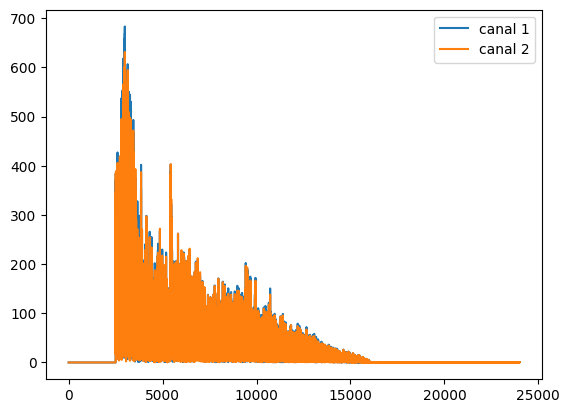

In [ ]:
#filtrar espectro pasaaltas
Xwf = Xw.copy()
f1 = 2500 #frecuencia en Hz corte 1
ind = ~((vf > f1)) #frecuencias eliminar-> recueder que ~ actua como negación
Xwf[ind,:] = 0
plt.plot(vf,abs(Xwf))
plt.legend(('canal 1','canal 2'))
plt.show()

In [ ]:
xe2 = np.fft.irfft(Xwf,axis=0) #fft inversa sobre los dos canales de audio
Audio(xe2[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

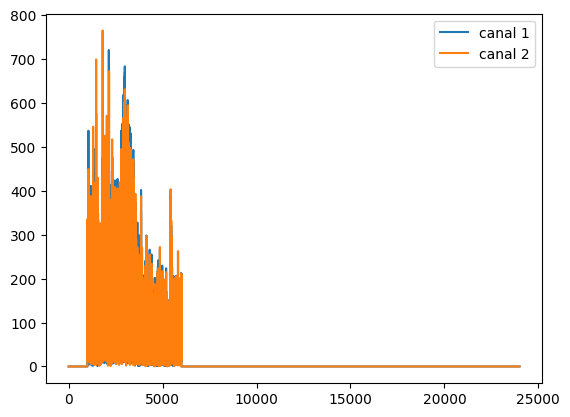

In [ ]:
#filtrar espectro pasabandas
Xwf = Xw.copy()
f1 = 1000 #frecuencia en Hz corte 1
f2 = 6000 #frecuencia en Hz corte 2
ind = ~((vf > f1) & (vf < f2)) #frecuencias eliminar-> recueder que ~ actua como negación
Xwf[ind,:] = 0
plt.plot(vf,abs(Xwf))
plt.legend(('canal 1','canal 2'))
plt.show()

In [ ]:
xe3 = np.fft.irfft(Xwf,axis=0) #fft inversa sobre los dos canales de audio
Audio(xe3[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

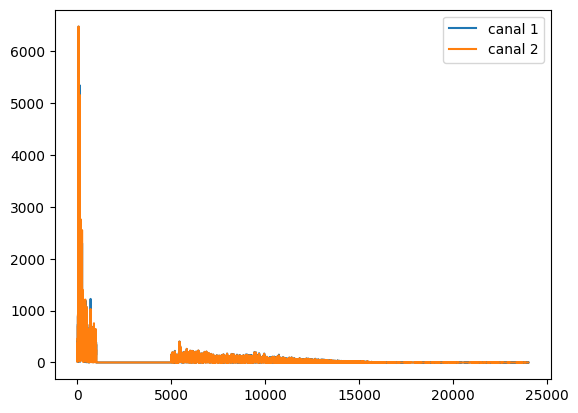

In [ ]:
#filtrar espectro pasabandas
Xwf = Xw.copy()
f1 = 1000 #frecuencia en Hz corte 1
f2 = 5000 #frecuencia en Hz corte 2
ind = ~((vf < f1) | (vf > f2)) #frecuencias eliminar-> recueder que ~ actua como negación
Xwf[ind,:] = 0
plt.plot(vf,abs(Xwf))
plt.legend(('canal 1','canal 2'))
plt.show()

In [ ]:
xe4 = np.fft.irfft(Xwf,axis=0) #fft inversa sobre los dos canales de audio
Audio(xe4[:int(fs*ns),:].T,rate=fs)#repoducir señal filtrada

In [ ]:
#Para guardar el audio en .wav
name_out_fil = 'new_file.wav'
sf.write(name_out_fil, xe2, fs)
print('Audio filtrado\n')

- Diseñe e implemente un detector de género musical, que permita diferenciar entre tres tipos de género. Para ello, construya una base de datos con al menos 30 registros por género musical, de 5 segundos cada uno, y luego implemente un código que permita recibir un nuevo registro músical de 5 segundos para detectar el género de la canción a partir de la distancia Euclídea entre la magnitud del espectro de Fourier del nuevo registro, y las magnitudes de los espectros de la base de datos construida (Ver [Cuaderno YouTube Download/Detector](https://github.com/amalvarezme/SenalesSistemas/blob/master/3_SerieyTransformadaFourier/youtube_detector.ipynb)).